In [1]:
import numpy as np
import astropy.units as u
import astropy.constants as const
from astropy.cosmology import FlatLambdaCDM
cosmo = FlatLambdaCDM(H0=70*u.km / (u.Mpc*u.s), Om0=0.286, Ob0=0.047)
import pickle
import math
import matplotlib.pyplot as plt

import os
#os.chdir('/home/finneas/Documents/COMAP/stacking')
#import lim_stacker as st

In [2]:
def linelum_to_flux(lum):

    dv = const.c * (3 * 0.03125 * u.GHz) / (30 * u.GHz)
    dv = dv.to(u.km / u.s)
    
    z_mean = 2.8
    v_obs = 30 * u.GHz
    
    cosmo = FlatLambdaCDM(H0=70*u.km / (u.Mpc*u.s), Om0=0.286, Ob0=0.047)
    DL = cosmo.luminosity_distance(z_mean)
    
    # convert input value to actual line luminosity units
    linelum = lum * u.K * (u.km / u.s) * (u.parsec**2)

    # Divides out the $(S \delta v)$ part of the L'CO equation
    lefthand = (const.c.cgs**2) / (2 * const.k_B.cgs)
    righthand = (DL**2) / ((v_obs**2) * ((1 + z_mean) ** 3))

    Snu = linelum / (lefthand * righthand)

    # 
    flux_density = (Snu / dv).to(u.Jy)
    newunit = u.erg / (u.s * (u.cm ** 2) * u.Hz)
    bandwidth = (v_obs.to(u.Hz))
    flux_density = flux_density.to(newunit) * bandwidth
    ap_width = 5 * (2 * u.arcminute) * (60 * u.arcsec) / (u.arcminute)
    ap_area = ap_width ** 2
    flux_density = flux_density / ap_area

    return flux_density

In [3]:
def freq_to_axion_mass(infreq):

    freq = infreq * u.GHz
    
    axmass_badunit = (4 * math.pi * freq) / (const.c)
    axmass_electrovolts = (axmass_badunit * const.h * const.c).to(u.eV)\
    
    return axmass_electrovolts

equation 4 of https://journals.aps.org/prd/pdf/10.1103/PhysRevD.110.103007: 

\begin{equation}
    F = \frac{\Omega \epsilon_\mathrm{DM} \Sigma(R)}{4\pi (1+z)^4}
\end{equation}

I think there's an error in this function, and you should be dividing by omega?

In [6]:
DATA_FILE = '/home/finneas/Documents/COMAP/survey_outputs/output_QSO_og/results.pkl'

with open(DATA_FILE, 'rb') as f:
    data = pickle.load(f)

data['z'] = np.array([])
data['fluxdensity'] = np.array([])
data['dfluxdensity'] = np.array([])
data['axmass'] = np.array([])

#data = data1

In [31]:
DATA_FILE = '/home/finneas/Documents/COMAP/survey_outputs/output_BGS/results.pkl'

with open(DATA_FILE, 'rb') as f:
    data = pickle.load(f)

In [32]:
len(data['ncutouts'])

420

In [7]:
observe_freq = 30
for i in range(len(data['linelum'])):
    # linelum to flux density
    data['fluxdensity'] = np.append(data['fluxdensity'], np.float64(linelum_to_flux( data['linelum'][i].item() )))
    data['dfluxdensity'] = np.append(data['dfluxdensity'], np.float64(linelum_to_flux( data['dlinelum'][i].item() )))
    # frequency to redshift
    #data['z'] = np.append(data['z'], (data['centfreq'][i] / observe_freq) - 1)
    # frequency to axion mass
    data['axmass'] = np.append(data['axmass'], np.float64( freq_to_axion_mass(data['centfreq'][i].item()) ) )

#data1 = data

In [15]:
#freqrange = np.arange(39.0, 94.4, 0.1);
limits = np.array([])

In [16]:
Omega = ((2*u.arcmin).to(u.arcsec)*5)**2 # size of aperture
#M_stack = 3.65e13 * u.Msun # dark matter mass for HETDEX
M_stack = 6.68e13 * u.Msun # dark matter mass for DESI QSOs

for i in range(len(data['centfreq'])):
    restfreq = data['centfreq'][i]
    F = (((max(0, data['fluxdensity'][i]) + (5 * data['dfluxdensity'][i]))* u.erg/u.s/u.cm**2) / Omega) # replace with actual 5(?) sigma upper limits
    z = restfreq / 30 - 1
    
    Omega_kpc = ((2*5*u.arcmin / cosmo.arcsec_per_kpc_proper(z)).to(u.kpc))**2 
    Sigma_R = (M_stack / Omega_kpc).to(u.g/u.cm**2) # this actually comes out extremely close to the desi number (nice)

    eps_DM = F * 4*np.pi*(1+z)**4 * Omega / (Sigma_R) 

    Gamma = eps_DM / const.c**2
    Gamma.cgs

    lama = const.c / (restfreq*u.GHz)
    ma_wn = 4 * np.pi / lama
    ma = (ma_wn * const.h * const.c).to(u.eV)

    g = np.sqrt(Gamma.to(u.eV, equivalencies=u.spectral()) * 64 * np.pi / ma**3)
    #g.to(1/u.GeV, equivalencies=u.spectral())
    #print(g.to(1/u.GeV, equivalencies=u.spectral()).value)
    limits = np.append(limits, g.to(1/u.GeV, equivalencies=u.spectral()).value)
    
    

In [8]:
#data_hetdex_lae = data
#limits_hetdex_lae = limits
#data_qso = data
#limits_qso = limits
data_qso_og = data
#limits_qso_og = limits
#data_hetdex_lae = data
#limits_hetdex_lae = limits

In [18]:
print(len(limits_hetdex_lae))
print(len(limits_qso_og))

1754
1509


In [79]:
#np.savez('data_qso_og.npz', **data_qso_og)
#np.savez('limits_qso_og.npz', limits = limits_qso_og)

In [85]:
np.max(data_qso_og['centfreq'])

np.float64(179.40000000000214)

In [86]:
np.max(data_hetdex_lae['centfreq'])

np.float64(203.90000000000248)

In [34]:
len(limits_hlae)

1754

In [175]:
data['dfluxdensity'][1251]

np.float64(1.376353673357958e-23)

In [177]:
len(freqrange)

554

In [201]:
g.to(1/u.GeV, equivalencies=u.spectral())

<Quantity 1.51418158e-12 1 / GeV>

In [203]:
g.to(1/u.GeV, equivalencies=u.spectral()).value

np.float64(1.5141815767435291e-12)

1754


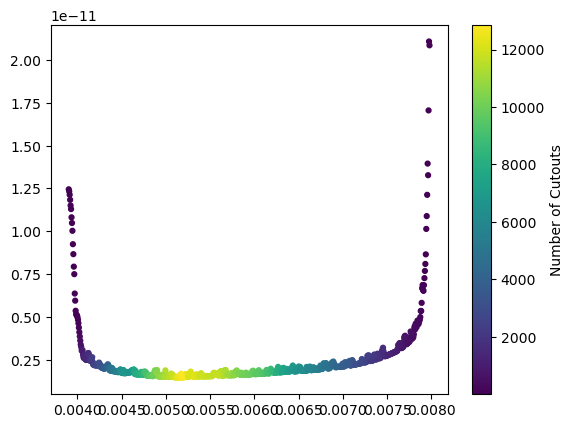

In [121]:
scatter = plt.scatter(data_hetdex_lae['axmass'], limits_hetdex_lae, c=data_hetdex_lae['ncutouts'] ,cmap='viridis', s=12)
plt.colorbar(scatter, label="Number of Cutouts")
print(len(limits_hetdex_lae))
#plt.errorbar(data['z'], data['fluxdensity'], yerr=data['dfluxdensity'], fmt='none', alpha=0.5)
#plt.axhline(y=0, color='black', alpha=0.2)

plt.show()

1509


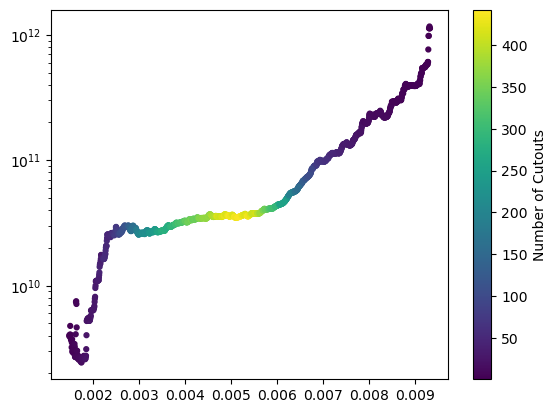

In [31]:
scatter = plt.scatter(data_qso_og['axmass'], data_qso_og['dlinelum'], c=data_qso_og['ncutouts'] ,cmap='viridis', s=12)
plt.colorbar(scatter, label="Number of Cutouts")
plt.yscale('log')
print(len(limits_qso_og))
#plt.errorbar(data['z'], data['fluxdensity'], yerr=data['dfluxdensity'], fmt='none', alpha=0.5)
#plt.axhline(y=0, color='black', alpha=0.2)

plt.show()

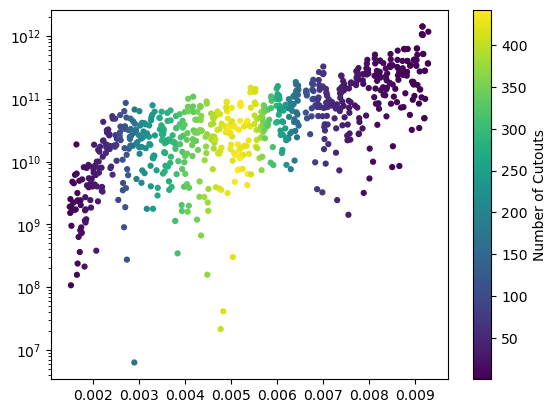

In [18]:
scatter = plt.scatter(data_qso_og['axmass'], data_qso_og['linelum'], c=data_qso_og['ncutouts'] ,cmap='viridis', s=12)
plt.colorbar(scatter, label="Number of Cutouts")
plt.yscale('log')
#print(len(limits_qso_og))
#plt.errorbar(data['z'], data['fluxdensity'], yerr=data['dfluxdensity'], fmt='none', alpha=0.5)
#plt.axhline(y=0, color='black', alpha=0.2)

plt.show()

In [ ]:
scatter = plt.scatter(data_qso['axmass'], limits_qso, c=data_qso['ncutouts'] ,cmap='viridis', s=12)
plt.colorbar(scatter, label="Number of Cutouts")
print(len(limits_qso))
#plt.errorbar(data['z'], data['fluxdensity'], yerr=data['dfluxdensity'], fmt='none', alpha=0.5)
#plt.axhline(y=0, color='black', alpha=0.2)

plt.show()

In [22]:
limits_qso_og_extended = np.append(limits_qso_og, np.full(245, np.nan))
data_qso_og_extended = np.append(data_qso_og['dfluxdensity'], np.full(245, np.nan))

In [25]:
weightmeaed = st.weightmean(np.array([limits_hetdex_lae, limits_qso_og_extended]), np.array([data_hetdex_lae['dfluxdensity'], data_qso_og_extended]), axis=0)

In [20]:
np.append(limits_qso_og, np.full(245, np.nan))

array([4.92456248e-14, 5.49708943e-14, 6.19076763e-14, ...,
                  nan,            nan,            nan], shape=(1754,))

In [102]:
len(data_qso_og['dfluxdensity'])

1754

In [99]:
len(limits_qso_og)

1754

In [92]:
[list(pair) for pair in zip(limits_hetdex_lae, limits_qso_og)]

[[np.float64(nan), np.float64(4.924562484588378e-14)],
 [np.float64(nan), np.float64(5.497089425504138e-14)],
 [np.float64(nan), np.float64(6.190767630472414e-14)],
 [np.float64(nan), np.float64(1.2077699801585733e-14)],
 [np.float64(nan), np.float64(2.1122394798103885e-14)],
 [np.float64(nan), np.float64(1.5459692935348835e-14)],
 [np.float64(nan), np.float64(2.637392363970769e-14)],
 [np.float64(nan), np.float64(2.943729862424909e-14)],
 [np.float64(nan), np.float64(7.844401811265408e-15)],
 [np.float64(nan), np.float64(4.8639841687825145e-14)],
 [np.float64(nan), np.float64(4.2516929392564194e-15)],
 [np.float64(nan), np.float64(4.1896151063649433e-14)],
 [np.float64(nan), np.float64(3.499776414663049e-14)],
 [np.float64(nan), np.float64(7.013349246561368e-14)],
 [np.float64(nan), np.float64(2.4806740895730158e-14)],
 [np.float64(nan), np.float64(1.2373647580439967e-14)],
 [np.float64(nan), np.float64(0.0)],
 [np.float64(nan), np.float64(8.290926801479296e-15)],
 [np.float64(nan), n

In [122]:
limits_hetdex_lae

array([           nan,            nan,            nan, ...,
       3.49213121e-12, 3.37462994e-12, 3.33886799e-12], shape=(1754,))

In [27]:
data = np.column_stack((data_hetdex_lae['axmass'], weightmeaed[0]))

np.savetxt("averaged_limits.txt", data, fmt="%.30f", delimiter="  ")